# This notebook visualizes input datasets used in GIPI for NYC 
##### Author: Omid Emamjomehzadeh (https://www.omidemam.com/)
##### Supervisor: Dr. Omar Wani (https://engineering.nyu.edu/faculty/omar-wani)
##### Hydrologic Systems Group @NYU (https://www.omarwani.com/)

In [ ]:
# import libraries
import os
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
import rasterio

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from rasterio.mask import mask
from rasterio.io import MemoryFile
from rasterio.windows import from_bounds
from rasterio.features import geometry_mask
from rasterio.transform import Affine, from_bounds as rio_from_bounds
from rasterio.warp import calculate_default_transform, reproject, Resampling

from mpl_toolkits.mplot3d import Axes3D

os.environ["OMP_NUM_THREADS"] = "1"

## NYC

Original CRS: EPSG:2263


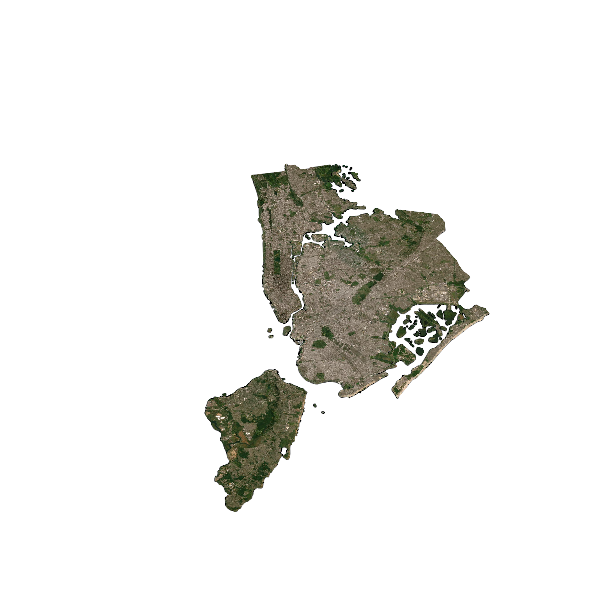

In [ ]:
# -----------------------------
# Read NYC boundary shapefile
# -----------------------------
shp_path = r"D:\GIPI data\Nate_data\NYCbound\NYCBound.shp"
gdf = gpd.read_file(shp_path)

print("Original CRS:", gdf.crs)

nyc = gdf.dissolve()
nyc_3857 = nyc.to_crs(epsg=3857)

# -----------------------------
# Bounds
# -----------------------------
xmin, ymin, xmax, ymax = nyc_3857.total_bounds
pad_x = 0.03 * (xmax - xmin)
pad_y = 0.03 * (ymax - ymin)

xmin_p = xmin - pad_x
xmax_p = xmax + pad_x
ymin_p = ymin - pad_y
ymax_p = ymax + pad_y

# -----------------------------
# Download imagery
# -----------------------------
img, ext = cx.bounds2img(
    xmin_p, ymin_p, xmax_p, ymax_p,
    zoom=11,
    source=cx.providers.Esri.WorldImagery
)

img = np.asarray(img)

if img.ndim == 3:
    if img.shape[0] in [3, 4] and img.shape[1] > 4 and img.shape[2] > 4:
        img = np.transpose(img, (1, 2, 0))
    elif img.shape[2] in [3, 4]:
        pass
    else:
        raise ValueError(f"Unexpected image shape: {img.shape}")
else:
    raise ValueError(f"Expected 3D image array, got {img.shape}")

left, right, bottom, top = ext
height, width = img.shape[:2]

transform = from_bounds(left, bottom, right, top, width, height)

mask = geometry_mask(
    nyc_3857.geometry,
    transform=transform,
    invert=True,
    out_shape=(height, width)
)

# -----------------------------
# Make RGBA
# -----------------------------
if img.shape[2] == 3:
    alpha_val = 255 if not np.issubdtype(img.dtype, np.floating) else 1.0
    alpha = np.full((height, width, 1), alpha_val, dtype=img.dtype)
    img_rgba = np.concatenate([img, alpha], axis=2)
else:
    img_rgba = img.copy()

if np.issubdtype(img_rgba.dtype, np.floating):
    img_rgba[~mask, 3] = 0.0
else:
    img_rgba[~mask, 3] = 0

# -----------------------------
# 3D grid
# -----------------------------
xs = np.linspace(left, right, width)
ys = np.linspace(bottom, top, height)
X, Y = np.meshgrid(xs, ys)
Z = np.zeros_like(X, dtype=float)

facecolors = np.flipud(img_rgba).astype(float)
if facecolors.max() > 1:
    facecolors /= 255.0

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X, Y, Z,
    facecolors=facecolors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False
)

# Boundary slightly above image plane
for geom in nyc_3857.geometry:
    if geom.geom_type == "Polygon":
        xg, yg = geom.exterior.xy
        ax.plot(xg, yg, zs=0.001, color="black", linewidth=1.2)
        for interior in geom.interiors:
            xg, yg = interior.xy
            ax.plot(xg, yg, zs=0.001, color="black", linewidth=0.8)

    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            xg, yg = poly.exterior.xy
            ax.plot(xg, yg, zs=0.001, color="black", linewidth=1.2)
            for interior in poly.interiors:
                xg, yg = interior.xy
                ax.plot(xg, yg, zs=0.001, color="black", linewidth=0.8)

padx = 0.005 * (xmax_p - xmin_p)
pady = 0.005 * (ymax_p - ymin_p)

ax.set_xlim(xmin_p - padx, xmax_p + padx)
ax.set_ylim(ymin_p - pady, ymax_p + pady)
ax.set_zlim(0, 1)

ax.set_box_aspect((xmax_p - xmin_p, ymax_p - ymin_p, 0.18 * (ymax_p - ymin_p)))
ax.view_init(elev=50, azim=-120)
ax.grid(False)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    r"D:\GIPI data\Figures\Imagery.png",
    dpi=1000,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

## Precipitation

Original CRS: EPSG:2263
Raster CRS: EPSG:4269


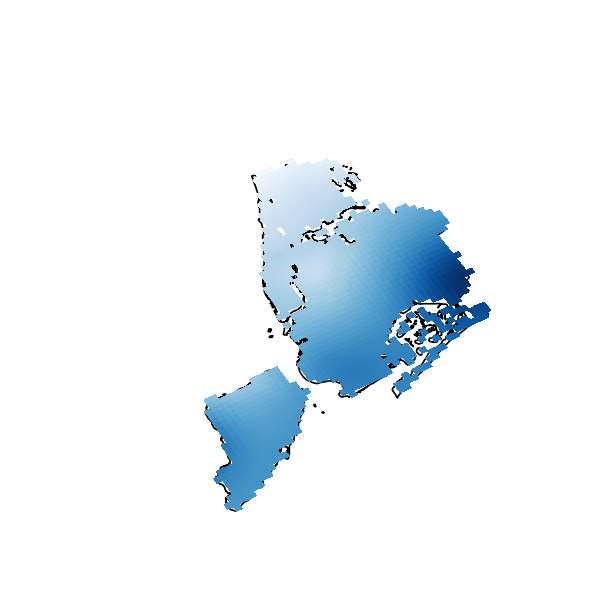

In [ ]:
# -----------------------------
# INPUTS
# -----------------------------
shp_path = r"D:\GIPI data\Nate_data\NYCbound\NYCBound.shp"
folder = f'ne50yr60ma_ams'

idf_file = 'ne50yr60ma_ams.asc'
idf_path = rf"D:\culvert repo\data\NOAA IDF\{folder}\{idf_file}"

precip_path = rf"D:\culvert repo\data\NOAA IDF\{folder}\{idf_file}"   # <-- change this

# -----------------------------
# Read NYC boundary
# -----------------------------
gdf = gpd.read_file(shp_path)
print("Original CRS:", gdf.crs)

nyc = gdf.dissolve()
nyc_3857 = nyc.to_crs(epsg=3857)

# -----------------------------
# Read precipitation raster
# Reproject to EPSG:3857
# -----------------------------
with rasterio.open(precip_path) as src:
    print("Raster CRS:", src.crs)

    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs, "EPSG:3857", src.width, src.height, *src.bounds
    )

    profile = src.profile.copy()
    profile.update({
        "crs": "EPSG:3857",
        "transform": dst_transform,
        "width": dst_width,
        "height": dst_height,
        "dtype": "float32"
    })

    with MemoryFile() as memfile:
        with memfile.open(**profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs="EPSG:3857",
                resampling=Resampling.bilinear
            )

            # clip to NYC boundary
            out_img, out_transform = mask(
                dst,
                nyc_3857.geometry,
                crop=True,
                filled=True,
                nodata=np.nan
            )

ppt = out_img[0].astype(float)

# remove common invalid values if present
ppt[ppt <= -9990] = np.nan

# -----------------------------
# Build raster extent
# -----------------------------
height, width = ppt.shape

left = out_transform.c
top = out_transform.f
right = left + out_transform.a * width
bottom = top + out_transform.e * height

# -----------------------------
# Add small padding like your map
# -----------------------------
xmin, ymin, xmax, ymax = nyc_3857.total_bounds
pad_x = 0.03 * (xmax - xmin)
pad_y = 0.03 * (ymax - ymin)

xmin_p = xmin - pad_x
xmax_p = xmax + pad_x
ymin_p = ymin - pad_y
ymax_p = ymax + pad_y

# -----------------------------
# Create colormap
# transparent outside NYC
# -----------------------------
cmap = plt.cm.Blues.copy()
cmap.set_bad((1, 1, 1, 0))

vmin = np.nanmin(ppt)
vmax = np.nanmax(ppt)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

facecolors = cmap(norm(ppt)).astype(float)

# -----------------------------
# 3D grid
# -----------------------------
xs = np.linspace(left, right, width)
ys = np.linspace(bottom, top, height)
X, Y = np.meshgrid(xs, ys)
Z = np.zeros_like(X, dtype=float)

# If orientation looks upside down, replace ppt with np.flipud(ppt)
# and also use:
facecolors = np.flipud(facecolors)

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X, Y, Z,
    facecolors=facecolors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False
)

# -----------------------------
# NYC boundary slightly above raster
# -----------------------------
for geom in nyc_3857.geometry:
    if geom.geom_type == "Polygon":
        xg, yg = geom.exterior.xy
        ax.plot(xg, yg, zs=0.001, color="black", linewidth=1.2)
        for interior in geom.interiors:
            xg, yg = interior.xy
            ax.plot(xg, yg, zs=0.001, color="black", linewidth=0.8)

    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            xg, yg = poly.exterior.xy
            ax.plot(xg, yg, zs=0.001, color="black", linewidth=1.2)
            for interior in poly.interiors:
                xg, yg = interior.xy
                ax.plot(xg, yg, zs=0.001, color="black", linewidth=0.8)

# -----------------------------
# Axes limits and style
# -----------------------------
padx = 0.005 * (xmax_p - xmin_p)
pady = 0.005 * (ymax_p - ymin_p)

ax.set_xlim(xmin_p - padx, xmax_p + padx)
ax.set_ylim(ymin_p - pady, ymax_p + pady)
ax.set_zlim(0, 1)

ax.set_box_aspect((xmax_p - xmin_p, ymax_p - ymin_p, 0.18 * (ymax_p - ymin_p)))

# your preferred perspective
ax.view_init(elev=50, azim=-120)

ax.grid(False)
ax.set_axis_off()

# -----------------------------
# Colorbar
# -----------------------------
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([])

plt.tight_layout()
plt.savefig(
    r"D:\GIPI data\Figures\precipitation.png",
    dpi=1000,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

## CSO

NYC CRS: EPSG:2263
CSO CRS: EPSG:4326
CSO points within NYC: 239


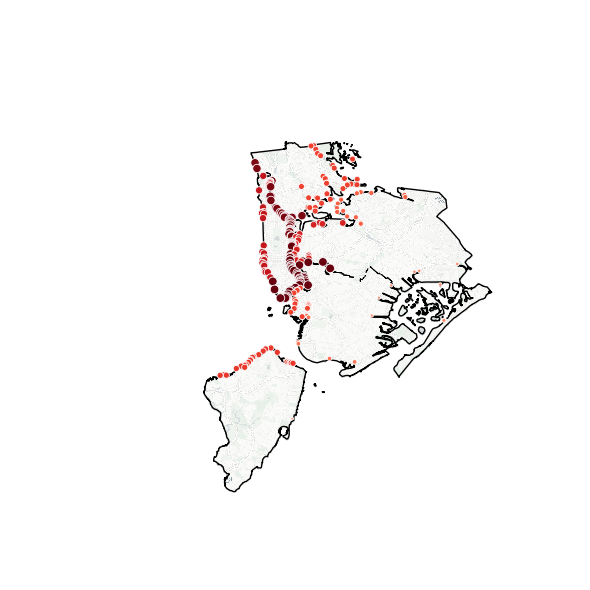

In [ ]:
# -----------------------------
# INPUTS
# -----------------------------
shp_path = r"D:\GIPI data\Nate_data\NYCbound\NYCBound.shp"
cso_path = r"D:\GIPI data\CSO\geo_export_02091e74-0223-472a-b735-1e0478c60efc.shp"

# field controlling magnitude
size_field = 'number_of_'

# -----------------------------
# Read NYC boundary
# -----------------------------
gdf = gpd.read_file(shp_path)
print("NYC CRS:", gdf.crs)

nyc = gdf.dissolve()
nyc_3857 = nyc.to_crs(epsg=3857)

# -----------------------------
# Bounds
# -----------------------------
xmin, ymin, xmax, ymax = nyc_3857.total_bounds
pad_x = 0.03 * (xmax - xmin)
pad_y = 0.03 * (ymax - ymin)

xmin_p = xmin - pad_x
xmax_p = xmax + pad_x
ymin_p = ymin - pad_y
ymax_p = ymax + pad_y

# -----------------------------
# Positron basemap tiles
# -----------------------------
img, ext = ctx.bounds2img(
    xmin_p, ymin_p, xmax_p, ymax_p,
    zoom=11,
    source=ctx.providers.CartoDB.Positron
)

img = np.asarray(img)

if img.ndim != 3:
    raise ValueError(f"Expected 3D image array, got {img.shape}")

if img.shape[0] in [3, 4] and img.shape[1] > 4 and img.shape[2] > 4:
    img = np.transpose(img, (1, 2, 0))
elif img.shape[2] in [3, 4]:
    pass
else:
    raise ValueError(f"Unexpected image shape: {img.shape}")

left, right, bottom, top = ext
height, width = img.shape[:2]

transform = from_bounds(left, bottom, right, top, width, height)

mask = geometry_mask(
    nyc_3857.geometry,
    transform=transform,
    invert=True,
    out_shape=(height, width)
)

# -----------------------------
# Make RGBA and clip to NYC
# -----------------------------
if img.shape[2] == 3:
    alpha = np.full((height, width, 1), 255, dtype=img.dtype)
    img_rgba = np.concatenate([img, alpha], axis=2)
else:
    img_rgba = img.copy()

img_rgba[~mask, 3] = 0

# -----------------------------
# 3D plane for basemap
# -----------------------------
xs = np.linspace(left, right, width)
ys = np.linspace(bottom, top, height)
X, Y = np.meshgrid(xs, ys)
Z = np.zeros_like(X, dtype=float)

facecolors = np.flipud(img_rgba).astype(float)
if facecolors.max() > 1:
    facecolors /= 255.0

# -----------------------------
# Read CSO points
# -----------------------------
cso = gpd.read_file(cso_path)
print("CSO CRS:", cso.crs)

if cso.crs is None:
    raise ValueError("CSO shapefile has no CRS.")

cso_3857 = cso.to_crs(epsg=3857)

# keep only points within NYC
cso_nyc = gpd.sjoin(
    cso_3857,
    nyc_3857[['geometry']],
    predicate='within',
    how='inner'
).copy()

print("CSO points within NYC:", len(cso_nyc))

if len(cso_nyc) == 0:
    raise ValueError("No CSO points found within NYC boundary.")

if size_field not in cso_nyc.columns:
    raise ValueError(f"'{size_field}' not found in CSO data.")

vals = pd.to_numeric(cso_nyc[size_field], errors='coerce')
valid = vals.notna() & np.isfinite(vals)

cso_nyc = cso_nyc.loc[valid].copy()
vals = vals.loc[valid].astype(float)

if len(cso_nyc) == 0:
    raise ValueError(f"No valid numeric values found in '{size_field}'.")

# -----------------------------
# Magnitude -> size and color
# -----------------------------
vmin = vals.min()
vmax = vals.max()

if np.isclose(vmin, vmax):
    sizes = np.full(len(vals), 80.0)
    colors = np.tile(np.array([[0.55, 0.0, 0.0, 1.0]]), (len(vals), 1))
else:
    sizes = 4 + 35 * (vals - vmin) / (vmax - vmin)

    # light red -> dark red
    cmap = plt.cm.Reds
    norm_vals = (vals - vmin) / (vmax - vmin)
    colors = cmap(0.35 + 0.65 * norm_vals)

# coordinates
cso_x = cso_nyc.geometry.x.values
cso_y = cso_nyc.geometry.y.values

# -----------------------------
# Stronger Z separation
# -----------------------------
map_dx = xmax_p - xmin_p
map_dy = ymax_p - ymin_p
z_gap = 0.015 * map_dy

boundary_z = 0.35 * z_gap
point_z = 0.75 * z_gap
cso_z = np.full(len(cso_nyc), point_z)

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

# manual ordering helps with mplot3d
ax.computed_zorder = False

# optional, often gives a cleaner map-like look
# ax.set_proj_type('ortho')

# basemap surface
surf = ax.plot_surface(
    X, Y, Z,
    facecolors=facecolors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
    zorder=1
)

# force surface to sort behind
try:
    surf.set_zsort('min')
except Exception:
    pass

# boundary
for geom in nyc_3857.geometry:
    if geom.geom_type == "Polygon":
        xg, yg = geom.exterior.xy
        ax.plot(xg, yg, zs=boundary_z, color="black", linewidth=1.0, zorder=5)
        for interior in geom.interiors:
            xi, yi = interior.xy
            ax.plot(xi, yi, zs=boundary_z, color="black", linewidth=0.6, zorder=5)

    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            xg, yg = poly.exterior.xy
            ax.plot(xg, yg, zs=boundary_z, color="black", linewidth=1.0, zorder=5)
            for interior in poly.interiors:
                xi, yi = interior.xy
                ax.plot(xi, yi, zs=boundary_z, color="black", linewidth=0.6, zorder=5)

# CSO points
ax.scatter(
    cso_x, cso_y, cso_z,
    s=sizes,
    c=colors,
    edgecolors='white',
    linewidths=0.6,
    alpha=0.98,
    depthshade=False,
    zorder=10
)

# -----------------------------
# Style
# -----------------------------
padx = 0.005 * map_dx
pady = 0.005 * map_dy

ax.set_xlim(xmin_p - padx, xmax_p + padx)
ax.set_ylim(ymin_p - pady, ymax_p + pady)
ax.set_zlim(0, 1.2 * z_gap)
ax.set_box_aspect((map_dx, map_dy, 1.2 * z_gap))
ax.view_init(elev=50, azim=-120)

ax.grid(False)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    r"D:\GIPI data\Figures\CSO.png",
    dpi=1000,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

## Imprevious surface

Boundary CRS: EPSG:2263
Raster CRS: EPSG:3857
Raster nodata: -128.0
Impervious min/max: 0.0 100.0


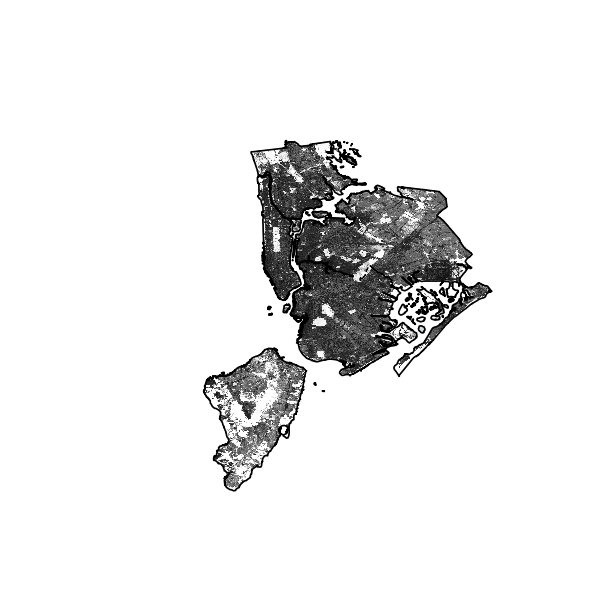

In [ ]:
# -----------------------------
# INPUTS
# -----------------------------
shp_path = r"D:\GIPI data\Nate_data\NYCbound\NYCBound.shp"
imperv_path = r"D:\GIPI data\Nate_data\NYC_Visualization\NYC_imperv_msk.tif"

# -----------------------------
# Read NYC boundary
# -----------------------------
gdf = gpd.read_file(shp_path)
print("Boundary CRS:", gdf.crs)

nyc = gdf.dissolve()
nyc_3857 = nyc.to_crs(epsg=3857)

# -----------------------------
# Padding from NYC boundary
# -----------------------------
xmin, ymin, xmax, ymax = nyc_3857.total_bounds
pad_x = 0.03 * (xmax - xmin)
pad_y = 0.03 * (ymax - ymin)

xmin_p = xmin - pad_x
xmax_p = xmax + pad_x
ymin_p = ymin - pad_y
ymax_p = ymax + pad_y

# -----------------------------
# Positron basemap tiles
# -----------------------------
img, ext = ctx.bounds2img(
    xmin_p, ymin_p, xmax_p, ymax_p,
    zoom=11,
    source=ctx.providers.CartoDB.Positron
)

img = np.asarray(img)

if img.ndim != 3:
    raise ValueError(f"Expected 3D basemap image, got {img.shape}")

if img.shape[0] in [3, 4] and img.shape[1] > 4 and img.shape[2] > 4:
    img = np.transpose(img, (1, 2, 0))
elif img.shape[2] in [3, 4]:
    pass
else:
    raise ValueError(f"Unexpected basemap image shape: {img.shape}")

left_b, right_b, bottom_b, top_b = ext
hb, wb = img.shape[:2]

transform_b = rio_from_bounds(left_b, bottom_b, right_b, top_b, wb, hb)
mask_b = geometry_mask(
    nyc_3857.geometry,
    transform=transform_b,
    invert=True,
    out_shape=(hb, wb)
)

if img.shape[2] == 3:
    alpha = np.full((hb, wb, 1), 255, dtype=img.dtype)
    img_rgba = np.concatenate([img, alpha], axis=2)
else:
    img_rgba = img.copy()

img_rgba[~mask_b, 3] = 0

base_facecolors = np.flipud(img_rgba).astype(float)
if base_facecolors.max() > 1:
    base_facecolors /= 255.0

xs_b = np.linspace(left_b, right_b, wb)
ys_b = np.linspace(bottom_b, top_b, hb)
Xb, Yb = np.meshgrid(xs_b, ys_b)
Zb = np.zeros_like(Xb, dtype=float)

# -----------------------------
# Read impervious raster
# Reproject to EPSG:3857
# -----------------------------
with rasterio.open(imperv_path) as src:
    print("Raster CRS:", src.crs)
    print("Raster nodata:", src.nodata)

    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs, "EPSG:3857", src.width, src.height, *src.bounds
    )

    profile = src.profile.copy()
    profile.update({
        "crs": "EPSG:3857",
        "transform": dst_transform,
        "width": dst_width,
        "height": dst_height,
        "dtype": "float32",
        "nodata": np.nan
    })

    with MemoryFile() as memfile:
        with memfile.open(**profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs="EPSG:3857",
                src_nodata=src.nodata,
                dst_nodata=np.nan,
                resampling=Resampling.bilinear
            )

            out_img, out_transform = mask(
                dst,
                nyc_3857.geometry,
                crop=True,
                filled=True,
                nodata=np.nan
            )

imperv = out_img[0].astype(float)
imperv[imperv <= -9990] = np.nan

if not np.isfinite(imperv).any():
    raise ValueError("All clipped raster values are NaN. Check CRS and overlap.")

print("Impervious min/max:", np.nanmin(imperv), np.nanmax(imperv))

# -----------------------------
# Impervious raster extent
# -----------------------------
height, width = imperv.shape

left = out_transform.c
top = out_transform.f
right = left + out_transform.a * width
bottom = top + out_transform.e * height

# -----------------------------
# Impervious colors
# white -> black
# -----------------------------
cmap = plt.cm.Greys.copy()
cmap.set_bad((1, 1, 1, 0))

vmin = np.nanmin(imperv)
vmax = np.nanmax(imperv)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

facecolors = cmap(norm(imperv)).astype(float)

# If orientation looks wrong, comment this out
facecolors = np.flipud(facecolors)

# -----------------------------
# 3D grid for impervious raster
# -----------------------------
xs = np.linspace(left, right, width)
ys = np.linspace(bottom, top, height)
X, Y = np.meshgrid(xs, ys)

# put impervious slightly above basemap
imperv_z = 0.002
Z = np.full_like(X, imperv_z, dtype=float)

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.computed_zorder = False

# Basemap plane
surf_base = ax.plot_surface(
    Xb, Yb, Zb,
    facecolors=base_facecolors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
    zorder=1
)

try:
    surf_base.set_zsort('min')
except Exception:
    pass

# Impervious plane
surf_imperv = ax.plot_surface(
    X, Y, Z,
    facecolors=facecolors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
    zorder=3
)

try:
    surf_imperv.set_zsort('max')
except Exception:
    pass

# Boundary above both
boundary_z = 0.004
for geom in nyc_3857.geometry:
    if geom.geom_type == "Polygon":
        xg, yg = geom.exterior.xy
        ax.plot(xg, yg, zs=boundary_z, color="black", linewidth=1.2, zorder=5)
        for interior in geom.interiors:
            xi, yi = interior.xy
            ax.plot(xi, yi, zs=boundary_z, color="black", linewidth=0.8, zorder=5)

    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            xg, yg = poly.exterior.xy
            ax.plot(xg, yg, zs=boundary_z, color="black", linewidth=1.2, zorder=5)
            for interior in poly.interiors:
                xi, yi = interior.xy
                ax.plot(xi, yi, zs=boundary_z, color="black", linewidth=0.8, zorder=5)

# -----------------------------
# Style
# -----------------------------
map_dx = xmax_p - xmin_p
map_dy = ymax_p - ymin_p

padx = 0.005 * map_dx
pady = 0.005 * map_dy

ax.set_xlim(xmin_p - padx, xmax_p + padx)
ax.set_ylim(ymin_p - pady, ymax_p + pady)
ax.set_zlim(0, 0.01)

ax.set_box_aspect((map_dx, map_dy, 0.01))
ax.view_init(elev=50, azim=-120)

ax.grid(False)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    r"D:\GIPI data\Figures\impervious.png",
    dpi=1000,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

## HS

Boundary CRS: EPSG:2263
Raster CRS: EPSG:3857
Raster nodata: None
Original heat raster shape: (2054, 2062)
Heat min/max: 0.0 5.0
Downsampled raster shape: (343, 344)


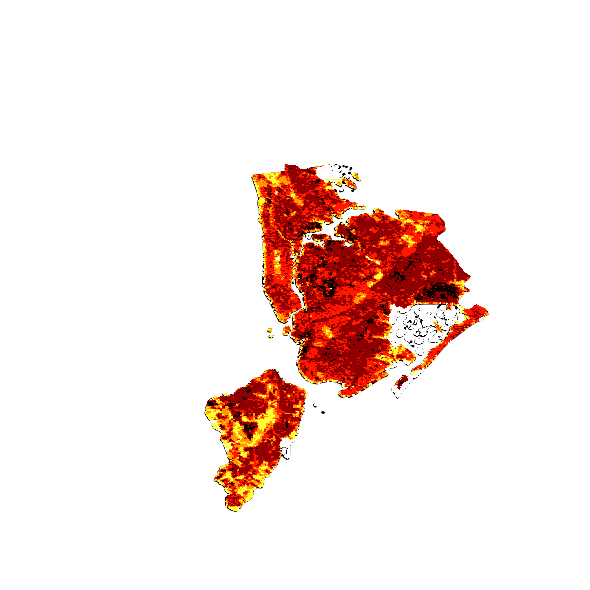

In [ ]:
# -----------------------------
# INPUTS
# -----------------------------
shp_path = r"D:\GIPI data\Nate_data\NYCbound\NYCBound.shp"
heat_path = r"D:\GIPI data\Nate_data\NYC_Visualization\NYC_heat.tif"

# optional: downsample for speed
max_side = 400

# -----------------------------
# Read NYC boundary
# -----------------------------
gdf = gpd.read_file(shp_path)
print("Boundary CRS:", gdf.crs)

nyc = gdf.dissolve()
nyc_3857 = nyc.to_crs(epsg=3857)

# -----------------------------
# Read heat raster
# Reproject to EPSG:3857
# -----------------------------
with rasterio.open(heat_path) as src:
    print("Raster CRS:", src.crs)
    print("Raster nodata:", src.nodata)

    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs, "EPSG:3857", src.width, src.height, *src.bounds
    )

    profile = src.profile.copy()
    profile.update({
        "crs": "EPSG:3857",
        "transform": dst_transform,
        "width": dst_width,
        "height": dst_height,
        "dtype": "float32",
        "nodata": np.nan
    })

    with MemoryFile() as memfile:
        with memfile.open(**profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs="EPSG:3857",
                src_nodata=src.nodata,
                dst_nodata=np.nan,
                resampling=Resampling.bilinear
            )

            out_img, out_transform = mask(
                dst,
                nyc_3857.geometry,
                crop=True,
                filled=True,
                nodata=np.nan
            )

heat = out_img[0].astype(float)

# clean nodata remnants
heat[heat <= -9990] = np.nan

if not np.isfinite(heat).any():
    raise ValueError("All clipped raster values are NaN. Check CRS and overlap.")

print("Original heat raster shape:", heat.shape)
print("Heat min/max:", np.nanmin(heat), np.nanmax(heat))

# -----------------------------
# Downsample for faster plotting
# -----------------------------
nrows, ncols = heat.shape
rstep = max(1, int(np.ceil(nrows / max_side)))
cstep = max(1, int(np.ceil(ncols / max_side)))

heat_small = heat[::rstep, ::cstep]
print("Downsampled raster shape:", heat_small.shape)

# -----------------------------
# Raster extent
# -----------------------------
height, width = heat.shape

left = out_transform.c
top = out_transform.f
right = left + out_transform.a * width
bottom = top + out_transform.e * height

# -----------------------------
# Padding from NYC boundary
# -----------------------------
xmin, ymin, xmax, ymax = nyc_3857.total_bounds
pad_x = 0.03 * (xmax - xmin)
pad_y = 0.03 * (ymax - ymin)

xmin_p = xmin - pad_x
xmax_p = xmax + pad_x
ymin_p = ymin - pad_y
ymax_p = ymax + pad_y

# -----------------------------
# Colormap for heat
# -----------------------------
cmap = plt.cm.hot_r.copy()
cmap.set_bad((1, 1, 1, 0))  # transparent outside NYC

vmin = np.nanmin(heat_small)
vmax = np.nanmax(heat_small)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

facecolors = cmap(norm(heat_small)).astype(float)

# If orientation looks wrong, remove this line
facecolors = np.flipud(facecolors)

# -----------------------------
# 3D grid
# -----------------------------
xs = np.linspace(left, right, width)[::cstep]
ys = np.linspace(bottom, top, height)[::rstep]
X, Y = np.meshgrid(xs, ys)
Z = np.zeros_like(X, dtype=float)

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X, Y, Z,
    facecolors=facecolors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False
)

# Boundary slightly above surface
for geom in nyc_3857.geometry:
    if geom.geom_type == "Polygon":
        xg, yg = geom.exterior.xy
        ax.plot(xg, yg, zs=0.001, color="black", linewidth=1.2)
        for interior in geom.interiors:
            xi, yi = interior.xy
            ax.plot(xi, yi, zs=0.001, color="black", linewidth=0.8)

    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            xg, yg = poly.exterior.xy
            ax.plot(xg, yg, zs=0.001, color="black", linewidth=1.2)
            for interior in poly.interiors:
                xi, yi = interior.xy
                ax.plot(xi, yi, zs=0.001, color="black", linewidth=0.8)

# -----------------------------
# Style
# -----------------------------
padx = 0.005 * (xmax_p - xmin_p)
pady = 0.005 * (ymax_p - ymin_p)

ax.set_xlim(xmin_p - padx, xmax_p + padx)
ax.set_ylim(ymin_p - pady, ymax_p + pady)
ax.set_zlim(0, 1)

ax.set_box_aspect((xmax_p - xmin_p, ymax_p - ymin_p, 0.18 * (ymax_p - ymin_p)))
ax.view_init(elev=50, azim=-120)

ax.grid(False)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    r"D:\GIPI data\Figures\HS.png",
    dpi=1000,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

## Parking lots

Boundary CRS: EPSG:2263
Raster CRS: EPSG:3857
Raster nodata: 65535.0
Original window size: 61261 61353
Downsampled read size: 500 500
Final raster shape: (500, 500)
Parking min/max: 21.0 39179.0


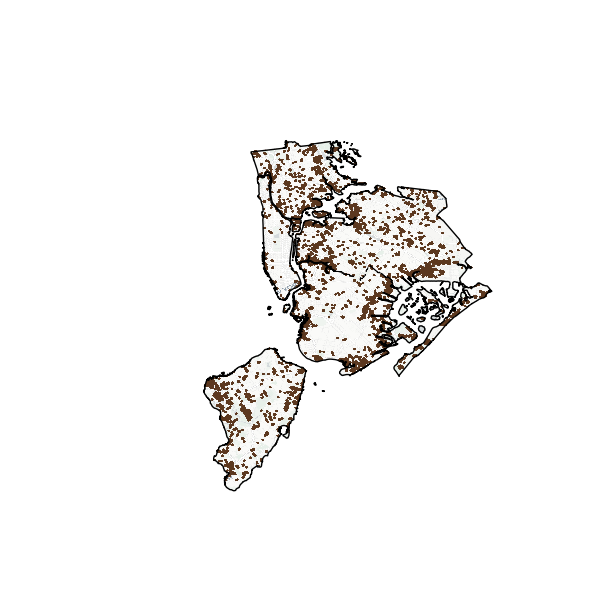

In [ ]:
# -----------------------------
# INPUTS
# -----------------------------
shp_path = r"D:\GIPI data\nybc boundary\nybb.shp"
parking_path = r"D:\GIPI data\Nate_data\NYC_Visualization\Parking lot\NYC_Prkng.tif"

# maximum plotted raster side
max_side = 500

# -----------------------------
# Read NYC boundary
# -----------------------------
gdf = gpd.read_file(shp_path)
print("Boundary CRS:", gdf.crs)

nyc = gdf.dissolve()
nyc_3857 = nyc.to_crs(epsg=3857)

# -----------------------------
# NYC bounds + padding
# -----------------------------
xmin, ymin, xmax, ymax = nyc_3857.total_bounds
pad_x = 0.03 * (xmax - xmin)
pad_y = 0.03 * (ymax - ymin)

xmin_p = xmin - pad_x
xmax_p = xmax + pad_x
ymin_p = ymin - pad_y
ymax_p = ymax + pad_y

# -----------------------------
# Positron basemap tiles
# -----------------------------
img, ext = ctx.bounds2img(
    xmin_p, ymin_p, xmax_p, ymax_p,
    zoom=11,
    source=ctx.providers.CartoDB.Positron
)

img = np.asarray(img)

if img.ndim != 3:
    raise ValueError(f"Expected 3D basemap image, got {img.shape}")

if img.shape[0] in [3, 4] and img.shape[1] > 4 and img.shape[2] > 4:
    img = np.transpose(img, (1, 2, 0))
elif img.shape[2] in [3, 4]:
    pass
else:
    raise ValueError(f"Unexpected basemap image shape: {img.shape}")

left_b, right_b, bottom_b, top_b = ext
h_b, w_b = img.shape[:2]

transform_b = rio_from_bounds(left_b, bottom_b, right_b, top_b, w_b, h_b)

mask_b = geometry_mask(
    nyc_3857.geometry,
    transform=transform_b,
    invert=True,
    out_shape=(h_b, w_b)
)

if img.shape[2] == 3:
    alpha = np.full((h_b, w_b, 1), 255, dtype=img.dtype)
    img_rgba = np.concatenate([img, alpha], axis=2)
else:
    img_rgba = img.copy()

img_rgba[~mask_b, 3] = 0

base_facecolors = np.flipud(img_rgba).astype(float)
if base_facecolors.max() > 1:
    base_facecolors /= 255.0

xs_b = np.linspace(left_b, right_b, w_b)
ys_b = np.linspace(bottom_b, top_b, h_b)
Xb, Yb = np.meshgrid(xs_b, ys_b)
Zb = np.zeros_like(Xb, dtype=float)

# -----------------------------
# Read raster window around NYC
# and downsample DURING read
# -----------------------------
with rasterio.open(parking_path) as src:
    print("Raster CRS:", src.crs)
    print("Raster nodata:", src.nodata)

    if src.crs is None:
        raise ValueError("Raster CRS is missing.")

    if src.crs.to_epsg() != 3857:
        raise ValueError(
            f"Raster CRS is {src.crs}, not EPSG:3857. "
            "This version assumes the raster is already in EPSG:3857."
        )

    win = from_bounds(xmin_p, ymin_p, xmax_p, ymax_p, src.transform)
    win = win.round_offsets().round_lengths()
    full_window = rasterio.windows.Window(0, 0, src.width, src.height)
    win = win.intersection(full_window)

    win_h = int(win.height)
    win_w = int(win.width)
    print("Original window size:", win_h, win_w)

    scale = max(win_h / max_side, win_w / max_side, 1.0)
    out_h = max(1, int(np.ceil(win_h / scale)))
    out_w = max(1, int(np.ceil(win_w / scale)))
    print("Downsampled read size:", out_h, out_w)

    parking = src.read(
        1,
        window=win,
        out_shape=(out_h, out_w),
        resampling=Resampling.bilinear
    ).astype("float32")

    win_transform = src.window_transform(win)
    out_transform = win_transform * Affine.scale(win_w / out_w, win_h / out_h)

    nodata = src.nodata

# -----------------------------
# Clean nodata
# -----------------------------
if nodata is not None:
    parking[parking == nodata] = np.nan

parking[parking <= -9990] = np.nan

# -----------------------------
# Mask outside NYC boundary
# now on the SMALL array
# -----------------------------
height, width = parking.shape

mask_arr = geometry_mask(
    nyc_3857.geometry,
    transform=out_transform,
    invert=True,
    out_shape=(height, width)
)

parking[~mask_arr] = np.nan

if not np.isfinite(parking).any():
    raise ValueError("All clipped raster values are NaN. Check overlap.")

print("Final raster shape:", parking.shape)
print("Parking min/max:", np.nanmin(parking), np.nanmax(parking))

# -----------------------------
# Raster extent
# -----------------------------
left = out_transform.c
top = out_transform.f
right = left + out_transform.a * width
bottom = top + out_transform.e * height

# -----------------------------
# Single brown color for parking
# -----------------------------
facecolors = np.zeros((height, width, 4), dtype=float)
facecolors[..., 3] = 0.0

brown_rgba = np.array([0.36, 0.22, 0.12, 0.95])

valid = np.isfinite(parking)
facecolors[valid] = brown_rgba

# If orientation looks wrong, comment this out
facecolors = np.flipud(facecolors)

# -----------------------------
# 3D grid for parking raster
# -----------------------------
xs = np.linspace(left, right, width)
ys = np.linspace(bottom, top, height)
X, Y = np.meshgrid(xs, ys)

# slightly above basemap
parking_z = 0.002
Z = np.full_like(X, parking_z, dtype=float)

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.computed_zorder = False

# basemap plane
surf_base = ax.plot_surface(
    Xb, Yb, Zb,
    facecolors=base_facecolors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
    zorder=1
)

try:
    surf_base.set_zsort('min')
except Exception:
    pass

# parking plane above basemap
surf_parking = ax.plot_surface(
    X, Y, Z,
    facecolors=facecolors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
    zorder=3
)

try:
    surf_parking.set_zsort('max')
except Exception:
    pass

# boundary above both
boundary_z = 0.004
for geom in nyc_3857.geometry:
    if geom.geom_type == "Polygon":
        xg, yg = geom.exterior.xy
        ax.plot(xg, yg, zs=boundary_z, color="black", linewidth=1.0, zorder=5)
        for interior in geom.interiors:
            xi, yi = interior.xy
            ax.plot(xi, yi, zs=boundary_z, color="black", linewidth=0.6, zorder=5)

    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            xg, yg = poly.exterior.xy
            ax.plot(xg, yg, zs=boundary_z, color="black", linewidth=1.0, zorder=5)
            for interior in poly.interiors:
                xi, yi = interior.xy
                ax.plot(xi, yi, zs=boundary_z, color="black", linewidth=0.6, zorder=5)

# -----------------------------
# Style
# -----------------------------
map_dx = xmax_p - xmin_p
map_dy = ymax_p - ymin_p

padx = 0.005 * map_dx
pady = 0.005 * map_dy

ax.set_xlim(xmin_p - padx, xmax_p + padx)
ax.set_ylim(ymin_p - pady, ymax_p + pady)
ax.set_zlim(0, 0.01)

ax.set_box_aspect((map_dx, map_dy, 0.01))
ax.view_init(elev=50, azim=-120)

ax.grid(False)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    r"D:\GIPI data\Figures\parking.png",
    dpi=1000,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

## Minimum temperature

Boundary CRS: EPSG:2263
Raster CRS: EPSG:4269
Raster nodata: -9999.0
Original window size: 53 71
Downsampled read size: 53 71
Final raster shape: (62, 63)
August Tmin normals min/max: 19.172462 20.87614


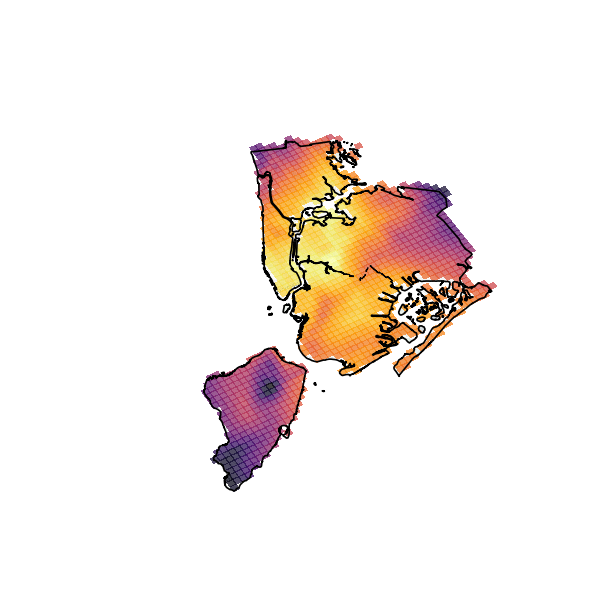

In [ ]:
# -----------------------------
# INPUTS
# -----------------------------
shp_path = r"D:\GIPI data\Nate_data\NYCbound\NYCBound.shp"
tmin_path = r"D:\GIPI data\Nate_data\NYC_Visualization\prism_tmin_us_30s_202008_avg_30y\prism_tmin_us_30s_202008_avg_30y.tif"

# maximum plotted raster side
max_side = 500

# -----------------------------
# Read NYC boundary
# -----------------------------
gdf = gpd.read_file(shp_path)
print("Boundary CRS:", gdf.crs)

nyc = gdf.dissolve()
nyc_3857 = nyc.to_crs(epsg=3857)

# -----------------------------
# NYC bounds + padding
# -----------------------------
xmin, ymin, xmax, ymax = nyc_3857.total_bounds
pad_x = 0.03 * (xmax - xmin)
pad_y = 0.03 * (ymax - ymin)

xmin_p = xmin - pad_x
xmax_p = xmax + pad_x
ymin_p = ymin - pad_y
ymax_p = ymax + pad_y

# -----------------------------
# Positron basemap tiles
# -----------------------------
img, ext = ctx.bounds2img(
    xmin_p, ymin_p, xmax_p, ymax_p,
    zoom=11,
    source=ctx.providers.CartoDB.Positron
)

img = np.asarray(img)

if img.ndim != 3:
    raise ValueError(f"Expected 3D basemap image, got {img.shape}")

if img.shape[0] in [3, 4] and img.shape[1] > 4 and img.shape[2] > 4:
    img = np.transpose(img, (1, 2, 0))
elif img.shape[2] in [3, 4]:
    pass
else:
    raise ValueError(f"Unexpected basemap image shape: {img.shape}")

left_b, right_b, bottom_b, top_b = ext
hb, wb = img.shape[:2]

transform_b = rio_from_bounds(left_b, bottom_b, right_b, top_b, wb, hb)
mask_b = geometry_mask(
    nyc_3857.geometry,
    transform=transform_b,
    invert=True,
    out_shape=(hb, wb)
)

if img.shape[2] == 3:
    alpha = np.full((hb, wb, 1), 255, dtype=img.dtype)
    img_rgba = np.concatenate([img, alpha], axis=2)
else:
    img_rgba = img.copy()

img_rgba[~mask_b, 3] = 0

base_facecolors = np.flipud(img_rgba).astype(float)
if base_facecolors.max() > 1:
    base_facecolors /= 255.0

xs_b = np.linspace(left_b, right_b, wb)
ys_b = np.linspace(bottom_b, top_b, hb)
Xb, Yb = np.meshgrid(xs_b, ys_b)
Zb = np.zeros_like(Xb, dtype=float)

# -----------------------------
# Read PRISM raster window around NYC
# and downsample DURING read
# -----------------------------
with rasterio.open(tmin_path) as src:
    print("Raster CRS:", src.crs)
    print("Raster nodata:", src.nodata)

    if src.crs is None:
        raise ValueError("Raster CRS is missing.")

    # PRISM raster is likely in geographic coordinates, so reproject bounds if needed
    if src.crs.to_epsg() == 3857:
        xmin_r, ymin_r, xmax_r, ymax_r = xmin_p, ymin_p, xmax_p, ymax_p
    else:
        nyc_src = nyc_3857.to_crs(src.crs)
        xmin_r, ymin_r, xmax_r, ymax_r = nyc_src.total_bounds
        pad_x_r = 0.03 * (xmax_r - xmin_r)
        pad_y_r = 0.03 * (ymax_r - ymin_r)
        xmin_r -= pad_x_r
        xmax_r += pad_x_r
        ymin_r -= pad_y_r
        ymax_r += pad_y_r

    win = from_bounds(xmin_r, ymin_r, xmax_r, ymax_r, src.transform)
    win = win.round_offsets().round_lengths()
    full_window = rasterio.windows.Window(0, 0, src.width, src.height)
    win = win.intersection(full_window)

    win_h = int(win.height)
    win_w = int(win.width)
    print("Original window size:", win_h, win_w)

    scale = max(win_h / max_side, win_w / max_side, 1.0)
    out_h = max(1, int(np.ceil(win_h / scale)))
    out_w = max(1, int(np.ceil(win_w / scale)))
    print("Downsampled read size:", out_h, out_w)

    tmin = src.read(
        1,
        window=win,
        out_shape=(out_h, out_w),
        resampling=Resampling.bilinear
    ).astype("float32")

    win_transform = src.window_transform(win)
    out_transform_src = win_transform * Affine.scale(win_w / out_w, win_h / out_h)
    nodata = src.nodata
    src_crs = src.crs

# -----------------------------
# Clean nodata
# -----------------------------
if nodata is not None:
    tmin[tmin == nodata] = np.nan

tmin[tmin <= -9990] = np.nan

# -----------------------------
# Reproject the SMALL raster to EPSG:3857 if needed
# -----------------------------
if src_crs.to_epsg() != 3857:
    from rasterio.warp import calculate_default_transform, reproject

    src_height, src_width = tmin.shape
    left_s = out_transform_src.c
    top_s = out_transform_src.f
    right_s = left_s + out_transform_src.a * src_width
    bottom_s = top_s + out_transform_src.e * src_height

    dst_transform, dst_width, dst_height = calculate_default_transform(
        src_crs, "EPSG:3857", src_width, src_height, left_s, bottom_s, right_s, top_s
    )

    tmin_3857 = np.full((dst_height, dst_width), np.nan, dtype=np.float32)

    reproject(
        source=tmin,
        destination=tmin_3857,
        src_transform=out_transform_src,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs="EPSG:3857",
        src_nodata=np.nan,
        dst_nodata=np.nan,
        resampling=Resampling.bilinear
    )

    tmin = tmin_3857
    out_transform = dst_transform
else:
    out_transform = out_transform_src

# -----------------------------
# Mask outside NYC boundary
# -----------------------------
height, width = tmin.shape

mask_arr = geometry_mask(
    nyc_3857.geometry,
    transform=out_transform,
    invert=True,
    out_shape=(height, width)
)

tmin[~mask_arr] = np.nan

if not np.isfinite(tmin).any():
    raise ValueError("All clipped raster values are NaN. Check overlap.")

print("Final raster shape:", tmin.shape)
print("August Tmin normals min/max:", np.nanmin(tmin), np.nanmax(tmin))

# -----------------------------
# Raster extent
# -----------------------------
left = out_transform.c
top = out_transform.f
right = left + out_transform.a * width
bottom = top + out_transform.e * height

# -----------------------------
# Heat colors
# -----------------------------
cmap = plt.cm.inferno.copy()
cmap.set_bad((1, 1, 1, 0))

vmin = np.nanmin(tmin)
vmax = np.nanmax(tmin)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

facecolors = cmap(norm(tmin)).astype(float)
facecolors[..., 3] = np.where(np.isfinite(tmin), 0.72, 0.0)

# If orientation looks wrong, comment this out
facecolors = np.flipud(facecolors)

# -----------------------------
# 3D grid for raster
# -----------------------------
xs = np.linspace(left, right, width)
ys = np.linspace(bottom, top, height)
X, Y = np.meshgrid(xs, ys)

tmin_z = 0.002
Z = np.full_like(X, tmin_z, dtype=float)

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.computed_zorder = False

surf_base = ax.plot_surface(
    Xb, Yb, Zb,
    facecolors=base_facecolors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
    zorder=1
)

try:
    surf_base.set_zsort('min')
except Exception:
    pass

surf_tmin = ax.plot_surface(
    X, Y, Z,
    facecolors=facecolors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
    zorder=3
)

try:
    surf_tmin.set_zsort('max')
except Exception:
    pass

boundary_z = 0.004
for geom in nyc_3857.geometry:
    if geom.geom_type == "Polygon":
        xg, yg = geom.exterior.xy
        ax.plot(xg, yg, zs=boundary_z, color="black", linewidth=1.2, zorder=5)
        for interior in geom.interiors:
            xi, yi = interior.xy
            ax.plot(xi, yi, zs=boundary_z, color="black", linewidth=0.8, zorder=5)

    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            xg, yg = poly.exterior.xy
            ax.plot(xg, yg, zs=boundary_z, color="black", linewidth=1.2, zorder=5)
            for interior in poly.interiors:
                xi, yi = interior.xy
                ax.plot(xi, yi, zs=boundary_z, color="black", linewidth=0.8, zorder=5)

# -----------------------------
# Style
# -----------------------------
map_dx = xmax_p - xmin_p
map_dy = ymax_p - ymin_p

padx = 0.005 * map_dx
pady = 0.005 * map_dy

ax.set_xlim(xmin_p - padx, xmax_p + padx)
ax.set_ylim(ymin_p - pady, ymax_p + pady)
ax.set_zlim(0, 0.01)

ax.set_box_aspect((map_dx, map_dy, 0.01))
ax.view_init(elev=50, azim=-120)

ax.grid(False)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    r"D:\GIPI data\Figures\mintemp.png",
    dpi=1000,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

## AQI

Boundary CRS: EPSG:2263
Raster CRS: EPSG:2263
Raster nodata: -9999.0
Original window size: 156 157
Downsampled read size: 156 157
Final raster shape: (156, 157)
Raster min/max: 3.5753808 42.016136


C:\Users\Omid Emamjomehzadeh\AppData\Local\Temp\ipykernel_15668\676636210.py:225: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


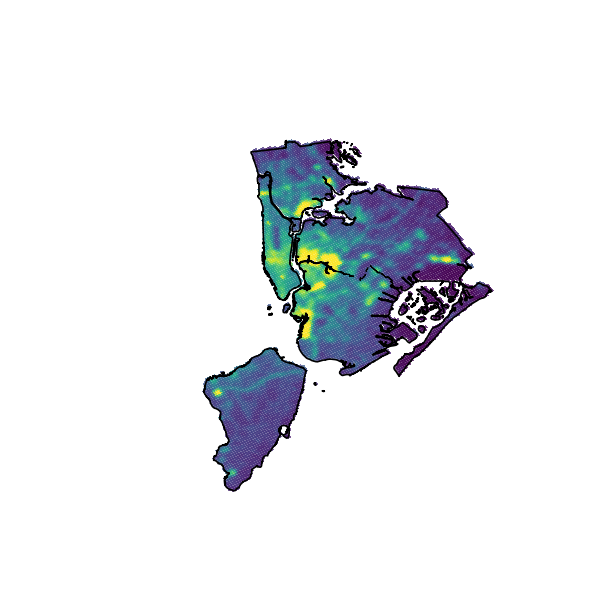

Saved to: D:\GIPI data\Figures\nyc_no_air_quality_3d.png


: 

In [ ]:

# =========================================================
# INPUTS
# =========================================================
shp_path = r"D:\GIPI data\Nate_data\NYCbound\NYCBound.shp"
raster_path = r"D:\GIPI data\Nate_data\AnnAvg_1_16_300m\aa16_no300m\noAA16300m.tif"
out_path = r"D:\GIPI data\Figures\nyc_no_air_quality_3d.png"

max_side = 500
zoom_level = 11
overlay_alpha = 0.72
surface_z = 0.002
boundary_z = 0.004
figsize = (6, 6)
dpi = 1000
cmap_name = "viridis"

use_percentile_stretch = True
pmin, pmax = 2, 98

# =========================================================
# READ NYC BOUNDARY
# =========================================================
gdf = gpd.read_file(shp_path)
print("Boundary CRS:", gdf.crs)

nyc = gdf.dissolve()
nyc_3857 = nyc.to_crs(epsg=3857)

# =========================================================
# NYC BOUNDS + PADDING
# =========================================================
xmin, ymin, xmax, ymax = nyc_3857.total_bounds
pad_x = 0.03 * (xmax - xmin)
pad_y = 0.03 * (ymax - ymin)

xmin_p = xmin - pad_x
xmax_p = xmax + pad_x
ymin_p = ymin - pad_y
ymax_p = ymax + pad_y

# =========================================================
# BASEMAP
# =========================================================
img, ext = ctx.bounds2img(
    xmin_p, ymin_p, xmax_p, ymax_p,
    zoom=zoom_level,
    source=ctx.providers.CartoDB.Positron
)

img = np.asarray(img)

if img.ndim != 3:
    raise ValueError(f"Expected 3D basemap image, got {img.shape}")

if img.shape[0] in [3, 4] and img.shape[1] > 4 and img.shape[2] > 4:
    img = np.transpose(img, (1, 2, 0))
elif img.shape[2] in [3, 4]:
    pass
else:
    raise ValueError(f"Unexpected basemap image shape: {img.shape}")

left_b, right_b, bottom_b, top_b = ext
hb, wb = img.shape[:2]

transform_b = rio_from_bounds(left_b, bottom_b, right_b, top_b, wb, hb)
mask_b = geometry_mask(
    nyc_3857.geometry,
    transform=transform_b,
    invert=True,
    out_shape=(hb, wb)
)

if img.shape[2] == 3:
    alpha = np.full((hb, wb, 1), 255, dtype=img.dtype)
    img_rgba = np.concatenate([img, alpha], axis=2)
else:
    img_rgba = img.copy()

img_rgba[~mask_b, 3] = 0

base_facecolors = np.flipud(img_rgba).astype(float)
if base_facecolors.max() > 1:
    base_facecolors /= 255.0

xs_b = np.linspace(left_b, right_b, wb)
ys_b = np.linspace(bottom_b, top_b, hb)
Xb, Yb = np.meshgrid(xs_b, ys_b)
Zb = np.zeros_like(Xb, dtype=float)

# =========================================================
# READ RASTER WINDOW AROUND NYC
# =========================================================
with rasterio.open(raster_path) as src:
    print("Raster CRS:", src.crs)
    print("Raster nodata:", src.nodata)

    if src.crs is None:
        raise ValueError("Raster CRS is missing.")

    if src.crs.to_epsg() == 3857:
        xmin_r, ymin_r, xmax_r, ymax_r = xmin_p, ymin_p, xmax_p, ymax_p
    else:
        nyc_src = nyc_3857.to_crs(src.crs)
        xmin_r, ymin_r, xmax_r, ymax_r = nyc_src.total_bounds
        pad_x_r = 0.03 * (xmax_r - xmin_r)
        pad_y_r = 0.03 * (ymax_r - ymin_r)
        xmin_r -= pad_x_r
        xmax_r += pad_x_r
        ymin_r -= pad_y_r
        ymax_r += pad_y_r

    win = from_bounds(xmin_r, ymin_r, xmax_r, ymax_r, src.transform)
    win = win.round_offsets().round_lengths()
    full_window = rasterio.windows.Window(0, 0, src.width, src.height)
    win = win.intersection(full_window)

    win_h = int(win.height)
    win_w = int(win.width)
    print("Original window size:", win_h, win_w)

    scale = max(win_h / max_side, win_w / max_side, 1.0)
    out_h = max(1, int(np.ceil(win_h / scale)))
    out_w = max(1, int(np.ceil(win_w / scale)))
    print("Downsampled read size:", out_h, out_w)

    aq = src.read(
        1,
        window=win,
        out_shape=(out_h, out_w),
        resampling=Resampling.bilinear
    ).astype("float32")

    win_transform = src.window_transform(win)
    out_transform_src = win_transform * Affine.scale(win_w / out_w, win_h / out_h)
    nodata = src.nodata
    src_crs = src.crs

# =========================================================
# CLEAN NODATA
# =========================================================
if nodata is not None:
    aq[aq == nodata] = np.nan

aq[~np.isfinite(aq)] = np.nan
aq[aq < -1e20] = np.nan

# =========================================================
# REPROJECT TO EPSG:3857 IF NEEDED
# =========================================================
if src_crs.to_epsg() != 3857:
    src_height, src_width = aq.shape

    left_s = out_transform_src.c
    top_s = out_transform_src.f
    right_s = left_s + out_transform_src.a * src_width
    bottom_s = top_s + out_transform_src.e * src_height

    dst_transform, dst_width, dst_height = calculate_default_transform(
        src_crs, "EPSG:3857",
        src_width, src_height,
        left_s, bottom_s, right_s, top_s
    )

    aq_3857 = np.full((dst_height, dst_width), np.nan, dtype=np.float32)

    reproject(
        source=aq,
        destination=aq_3857,
        src_transform=out_transform_src,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs="EPSG:3857",
        src_nodata=np.nan,
        dst_nodata=np.nan,
        resampling=Resampling.bilinear
    )

    aq = aq_3857
    out_transform = dst_transform
else:
    out_transform = out_transform_src

# =========================================================
# MASK OUTSIDE NYC
# =========================================================
height, width = aq.shape

mask_arr = geometry_mask(
    nyc_3857.geometry,
    transform=out_transform,
    invert=True,
    out_shape=(height, width)
)

aq[~mask_arr] = np.nan

if not np.isfinite(aq).any():
    raise ValueError("All clipped raster values are NaN. Check overlap / CRS / boundary.")

print("Final raster shape:", aq.shape)
print("Raster min/max:", np.nanmin(aq), np.nanmax(aq))

# =========================================================
# EXTENT
# =========================================================
left = out_transform.c
top = out_transform.f
right = left + out_transform.a * width
bottom = top + out_transform.e * height

# =========================================================
# COLORS
# =========================================================
cmap = plt.cm.get_cmap(cmap_name).copy()
cmap.set_bad((1, 1, 1, 0))

if use_percentile_stretch:
    valid = aq[np.isfinite(aq)]
    vmin = np.percentile(valid, pmin)
    vmax = np.percentile(valid, pmax)
else:
    vmin = np.nanmin(aq)
    vmax = np.nanmax(aq)

if np.isclose(vmin, vmax):
    vmax = vmin + 1e-6

norm = plt.Normalize(vmin=vmin, vmax=vmax)

facecolors = cmap(norm(aq)).astype(float)
facecolors[..., 3] = np.where(np.isfinite(aq), overlay_alpha, 0.0)

# If overlay looks upside down, keep this.
# If it looks flipped, comment this line out.
facecolors = np.flipud(facecolors)

# =========================================================
# 3D GRID
# =========================================================
xs = np.linspace(left, right, width)
ys = np.linspace(bottom, top, height)
X, Y = np.meshgrid(xs, ys)
Z = np.full_like(X, surface_z, dtype=float)

# =========================================================
# PLOT
# =========================================================
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection="3d")
ax.computed_zorder = False

surf_base = ax.plot_surface(
    Xb, Yb, Zb,
    facecolors=base_facecolors,
    rstride=1, cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
    zorder=1
)

try:
    surf_base.set_zsort("min")
except Exception:
    pass

surf_aq = ax.plot_surface(
    X, Y, Z,
    facecolors=facecolors,
    rstride=1, cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
    zorder=3
)

try:
    surf_aq.set_zsort("max")
except Exception:
    pass

for geom in nyc_3857.geometry:
    if geom.geom_type == "Polygon":
        xg, yg = geom.exterior.xy
        ax.plot(xg, yg, zs=boundary_z, color="black", linewidth=1.2, zorder=5)
        for interior in geom.interiors:
            xi, yi = interior.xy
            ax.plot(xi, yi, zs=boundary_z, color="black", linewidth=0.8, zorder=5)

    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            xg, yg = poly.exterior.xy
            ax.plot(xg, yg, zs=boundary_z, color="black", linewidth=1.2, zorder=5)
            for interior in poly.interiors:
                xi, yi = interior.xy
                ax.plot(xi, yi, zs=boundary_z, color="black", linewidth=0.8, zorder=5)

map_dx = xmax_p - xmin_p
map_dy = ymax_p - ymin_p
padx = 0.005 * map_dx
pady = 0.005 * map_dy

ax.set_xlim(xmin_p - padx, xmax_p + padx)
ax.set_ylim(ymin_p - pady, ymax_p + pady)
ax.set_zlim(0, 0.01)

ax.set_box_aspect((map_dx, map_dy, 0.01))
ax.view_init(elev=50, azim=-120)

ax.grid(False)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    out_path,
    dpi=dpi,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

print("Saved to:", out_path)